# TorchSpin — Performance versus EasySpin (MATLAB)

This notebook reproduces the tables of `benchmarks/results/BENCHMARK_REPORT.md` from the raw
campaign data in `benchmarks/results/workstation_20260902*/`, and times a few calls live on the current
machine.  The campaign (`benchmarks/cluster/run_workstation.sh`) ran on one 128-core workstation with two
RTX 4090s, strictly one job at a time: MATLAB R2026a + EasySpin, and torchspin at 1/8/32 threads,
on CUDA, and with worker processes, before (`workstation_20260902`) and after the two optimisation rounds
(`workstation_20260902_after`, `workstation_20260902_after2`).

The nine workloads are defined in `benchmarks/workloads/workloads.py` and mirrored one-to-one in
`benchmarks/workloads/matlab_workloads.m`.

> **Note.** The 2026-09-02 campaign shown here was later audited and partly retracted:
> three "CUDA" timings were actually CPU runs, the native BLAS/OpenMP thread pools were
> not controlled, and each point was a single call. The authoritative measurement is the
> matched-host rerun in
> `benchmarks/results/workstation_20260904_verified/BENCHMARK_VERIFICATION.md`
> (five replicates, medians with IQRs, per-workload device audit). Use this notebook to
> see how the campaign data is laid out, not as the source of performance numbers.


In [1]:
# setup: use the repository checkout if torchspin is not installed
import sys
from pathlib import Path
try:
    import torchspin  # noqa: F401
except ImportError:
    _root = Path.cwd()
    while not (_root / 'torchspin').exists() and _root != _root.parent:
        _root = _root.parent
    sys.path.insert(0, str(_root))

In [2]:
import json, sys, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd()
while not (ROOT / 'benchmarks').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
RES = ROOT / 'benchmarks' / 'results'
runs = {'baseline': RES / 'workstation_20260902', 'round 1': RES / 'workstation_20260902_after', 'round 2': RES / 'workstation_20260902_after2'}
sec = lambda d, f: json.load(open(d / f))['seconds']
matlab = sec(runs['baseline'], 'matlab_workloads.json')
names = list(matlab)
labels = {'pepper_cu_2n_matrix': 'pepper Cu 72-state', 'pepper_mn_S52_matrix': 'pepper Mn(II) 36-state', 'pepper_perturb_dense_grid': 'pepper perturb2 grid 91',
          'pepper_strain_summation': 'pepper strain 61×4', 'pepper_fit_loop_20': 'pepper fit loop ×20', 'chili_nitroxide_2nuc': 'chili nitroxide+1H',
          'chili_powder_potential': 'chili potential powder', 'saffron_hyscore_512': 'saffron HYSCORE 512²', 'cardamom_diffusion_200x1000': 'cardamom 200×1000'}
print('torch', torch.__version__)

torch 2.5.1+cu121


## 1. Wall time per workload: MATLAB vs torchspin (best CPU thread count and GPU)

In [3]:
def table(rows, cols, fmt='{:.2f}'):
    w = max(len(r[0]) for r in rows)
    print(' ' * w + ' | ' + ' | '.join(f'{c:>16s}' for c in cols))
    for r in rows:
        print(f'{r[0]:<{w}s} | ' + ' | '.join(f'{fmt.format(v):>16s}' for v in r[1:]))

cols = ['MATLAB'] + [f'{tag} {kind}' for tag in runs for kind in ('best CPU', 'GPU')] + ['MATLAB/round-2 CPU']
best = {tag: {n: min(sec(d, f'cpu_threads{t}.json')[n] for t in (1, 8, 32)) for n in names} for tag, d in runs.items()}
gpu = {tag: sec(d, 'gpu.json') for tag, d in runs.items()}
rows = [[labels[n], matlab[n]] + [v for tag in runs for v in (best[tag][n], gpu[tag][n])] + [matlab[n] / best['round 2'][n]] for n in names]
table(rows, cols)

                        |           MATLAB | baseline best CPU |     baseline GPU | round 1 best CPU |      round 1 GPU | round 2 best CPU |      round 2 GPU | MATLAB/round-2 CPU
pepper Cu 72-state      |             2.05 |            10.76 |            51.68 |             1.05 |             0.89 |             1.10 |             0.83 |             1.86
pepper Mn(II) 36-state  |             2.41 |            16.37 |           133.21 |             1.38 |             1.31 |             1.10 |             1.01 |             2.20
pepper perturb2 grid 91 |             0.19 |             0.50 |             0.59 |             0.06 |             0.15 |             0.07 |             0.16 |             2.71
pepper strain 61×4      |             1.01 |             3.19 |             7.16 |             2.14 |             5.00 |             1.00 |             1.36 |             1.01
pepper fit loop ×20     |             2.85 |            12.56 |            19.30 |             2.47 |             3.0

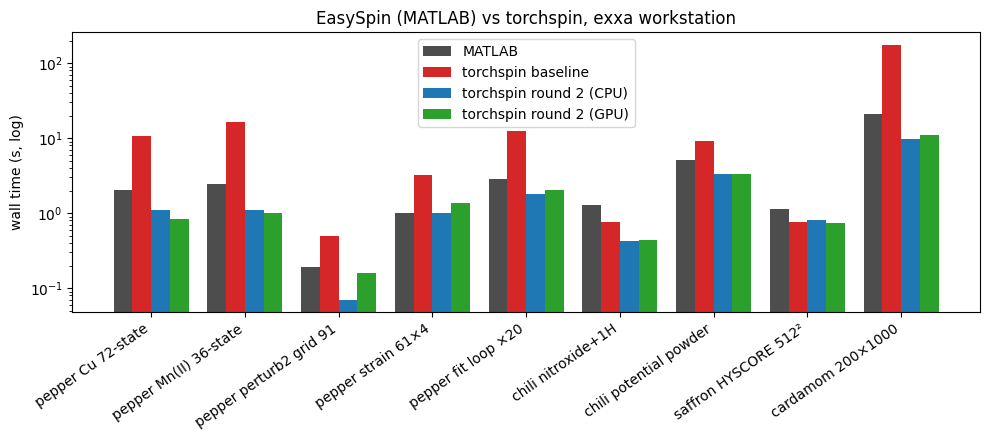

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(names)); w = 0.2
series = [('MATLAB', [matlab[n] for n in names], '0.3'), ('torchspin baseline', [best['baseline'][n] for n in names], 'tab:red'),
          ('torchspin round 2 (CPU)', [best['round 2'][n] for n in names], 'tab:blue'), ('torchspin round 2 (GPU)', [gpu['round 2'][n] for n in names], 'tab:green')]
for i, (lab, vals, c) in enumerate(series):
    ax.bar(x + (i - 1.5) * w, vals, w, label=lab, color=c)
ax.set_yscale('log'); ax.set_xticks(x); ax.set_xticklabels([labels[n] for n in names], rotation=35, ha='right'); ax.set_ylabel('wall time (s, log)')
ax.legend(); ax.set_title('EasySpin (MATLAB) vs torchspin, reference workstation'); plt.tight_layout()

## 2. Thread scaling (round 2)

The batched eigendecomposition and the accumulation run in thread pools (`torchspin/_linalg.py`), so the matrix-method workloads scale to ~8–32 cores; single-threaded torchspin is 2–4× slower than MATLAB on those.

                        |            1 thr |            8 thr |           32 thr |           MATLAB
pepper Cu 72-state      |             5.80 |             1.21 |             1.10 |             2.05
pepper Mn(II) 36-state  |             5.46 |             1.49 |             1.10 |             2.41
pepper perturb2 grid 91 |             0.07 |             0.07 |             0.08 |             0.19
pepper strain 61×4      |             3.78 |             1.00 |             1.29 |             1.01
pepper fit loop ×20     |             1.82 |             1.86 |             2.18 |             2.85
chili nitroxide+1H      |             0.42 |             0.63 |             0.63 |             1.27
chili potential powder  |             3.36 |             3.43 |             3.37 |             5.07
saffron HYSCORE 512²    |             4.25 |             1.12 |             0.81 |             1.14
cardamom 200×1000       |            20.95 |            11.43 |             9.82 |            20.83


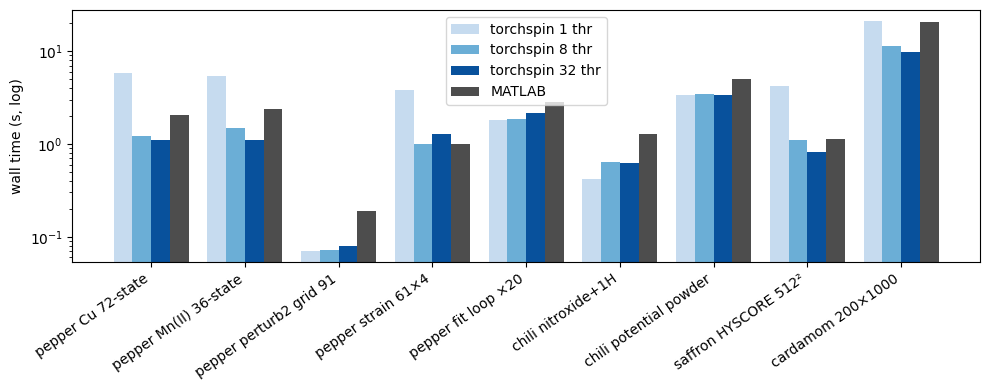

In [5]:
thr = {t: sec(runs['round 2'], f'cpu_threads{t}.json') for t in (1, 8, 32)}
fig, ax = plt.subplots(figsize=(10, 4)); w = 0.2
for i, (t, c) in enumerate([(1, '#c6dbef'), (8, '#6baed6'), (32, '#08519c')]):
    ax.bar(x + (i - 1.5) * w, [thr[t][n] for n in names], w, label=f'torchspin {t} thr', color=c)
ax.bar(x + 1.5 * w, [matlab[n] for n in names], w, label='MATLAB', color='0.3')
ax.set_yscale('log'); ax.set_xticks(x); ax.set_xticklabels([labels[n] for n in names], rotation=35, ha='right'); ax.set_ylabel('wall time (s, log)'); ax.legend(); plt.tight_layout()
table([[labels[n], thr[1][n], thr[8][n], thr[32][n], matlab[n]] for n in names], ['1 thr', '8 thr', '32 thr', 'MATLAB'])

## 3. Data-parallel fitting: worker processes

Independent forward calls (sweeps, population-based `esfit`) can be spread over processes.  For the 20-call fit loop the pool start-up dominates once a call takes ~0.1 s; for a swarm fit with hundreds of evaluations `FitOptions(n_workers=32)` gave 23.5 s → 4.1 s on the reference workstation.

In [6]:
rows = []
for tag, d in runs.items():
    rows.append([tag, sec(d, 'cpu_threads1.json')['pepper_fit_loop_20']] + [sec(d, f'cpu_procs{k}.json')[f'pepper_fit_loop_20_procs{k}'] for k in (4, 16, 64)])
table(rows, ['1 proc', '4 procs', '16 procs', '64 procs'])
print(f"MATLAB (serial): {matlab['pepper_fit_loop_20']:.2f} s")

         |           1 proc |          4 procs |         16 procs |         64 procs
baseline |            12.56 |             5.59 |             3.55 |             4.80
round 1  |             2.54 |             2.61 |             2.50 |             4.28
round 2  |             1.82 |             3.93 |             4.46 |             6.26
MATLAB (serial): 2.85 s


## 4. Live timing on this machine

A small interpolated-grid nitroxide (the fit-loop call) and the 36-state Mn(II) matrix workload, with the thread count torch picked for this machine.

In [7]:
sys.path.insert(0, str(ROOT / 'benchmarks' / 'workloads'))
from workloads import WORKLOADS
print('threads:', torch.get_num_threads())
for name in ['pepper_fit_loop_20', 'pepper_mn_S52_matrix']:
    fn = WORKLOADS[name](); fn()
    t = time.perf_counter(); fn(); dt = time.perf_counter() - t
    print(f'{labels[name]:28s} {dt:6.2f} s here   (ref 32 thr {sec(runs["round 2"], "cpu_threads32.json")[name]:.2f} s, MATLAB {matlab[name]:.2f} s)')

threads: 32


pepper fit loop ×20            1.76 s here   (ref 32 thr 2.18 s, MATLAB 2.85 s)


pepper Mn(II) 36-state         1.08 s here   (ref 32 thr 1.10 s, MATLAB 2.41 s)


## Summary

* With 8–32 threads torchspin is faster than EasySpin on all nine workloads (1.0–3×); single-threaded it is slower on the diagonalisation-bound cases.
* The GPU matches but does not beat the CPU pool for plain simulations (cuSOLVER batches only ≤ 32×32 matrices); its payoff is autograd and batched fitting — see `02_gpu_and_autograd.ipynb`.
* Details, profiles and the exact procedure: `benchmarks/results/BENCHMARK_REPORT.md`, `PERF_PLAN.md`.